# Module 2: Deep Agents

> Part of the **Modular Workshops** series. Standalone, ~60 min.

Deep Agents = `create_agent()` + a pre-built middleware stack (filesystem, planning, subagents, context management). We'll build up from a bare agent to a fully-featured **commodities trading assistant**, exploring:

- The harness and built-in tools
- Custom tools (Tavily search)
- Subagents and context isolation
- Backends and persistent memory
- Middleware (compliance, audit)
- Human-in-the-loop on tool calls
- AGENTS.md and Skills

> **Disclaimer:** The commodities examples in this workshop are illustrative and for educational purposes only. Anything the agent produces is **market color, not investment advice**, and no example uses live trading or real order execution.


## Setup

In [4]:
import sys
import logging
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils.models import model

from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command
from langsmith import uuid7
from IPython.display import Image, display

# LangSmith's tracer logs benign "No indexed run ID" warnings when Deep Agents
# runs tools/subagents on parallel threads. Traces still upload fine and
# execution is unaffected. Filter ONLY that message so real callback warnings
# stay visible.
class _NoIndexedRunIDFilter(logging.Filter):
    def filter(self, record):
        return "No indexed run ID" not in record.getMessage()

logging.getLogger("langchain_core.callbacks.manager").addFilter(_NoIndexedRunIDFilter())

# Start each run with a clean long-term memory store (section 1.4 recreates it).
for f in Path().glob("deep_agents_memory.db*"):
    f.unlink()

print("Ready")


Ready


---
# Part 1: Deep Agents

Deep Agents = `create_agent()` + a pre-built middleware stack (filesystem, planning, subagents, context management).

We'll build up from a bare agent to a fully-featured commodities trading assistant — the kind of desk analyst a trading partner might run to research markets, draft desk notes, and prep trade ideas.

## 1.1 Your First Deep Agent

`create_deep_agent()` gives you a filesystem, a todo list, and context management out of the box — no tools required.

<img src="../images/deepAgentsDiag.png" style="width: auto; max-height: 420px; border-radius: 8px;">

### What you get for free:

- **Filesystem Tools** — `ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep`
- **Planning Tool** — `write_todos` for task tracking
- **Subagent Delegation** — `task()` tool for isolated work
- **Large Tool Result Eviction** — Automatically offloads tool results >20k tokens to the filesystem
- **Conversation Summarization** — Compresses history when approaching ~85% context capacity
- **Dangling Tool Call Patching** — Fixes message history consistency automatically


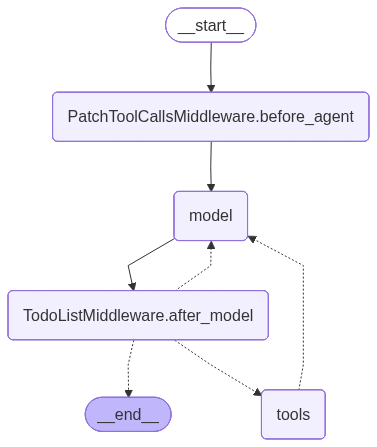

In [5]:
from deepagents import create_deep_agent

agent = create_deep_agent(
    model=model,
    system_prompt="You are a helpful assistant.",
    checkpointer=MemorySaver(),
)
agent

In [6]:
# The agent can already write and read files — these are built-in tools
config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Write a one-line morning market note on corn to /market_note.txt, then read it back to me."}]
}, config=config)

print(result["messages"][-1].content)

Morning market note: Corn prices are showing steady gains amid favorable weather forecasts and strong demand projections.


In [4]:
# Helper: print the virtual filesystem from a deep agent result.
def print_files(result, header="VIRTUAL FILESYSTEM (in-memory, not on disk!)"):
    files = result.get("files") or {}
    if not files:
        print("(no files in state)")
        return
    print("=" * 50)
    print(header)
    print("=" * 50)
    for path, file_data in files.items():
        print(f"\n  Path: {path!r}")
        print("  " + "-" * 38)
        content = file_data
        if isinstance(file_data, dict) and "content" in file_data:
            content = file_data["content"]
        if isinstance(content, list):
            content = "\n".join(content)
        for line in str(content).split("\n"):
            print(f"  | {line}")

print_files(result)


VIRTUAL FILESYSTEM (in-memory, not on disk!)

  Path: '/market_note.txt'
  --------------------------------------
  | Corn futures opened higher this morning, buoyed by favorable weather forecasts and strong export demand.


### Filesystem persistence within a thread

By default, `create_deep_agent()` uses **StateBackend** — files are stored in agent state and persist within a thread (via the checkpointer), but disappear when you start a new thread.

| Backend | Storage | Persistence | Use Case |
|---------|---------|-------------|----------|
| **StateBackend** | In-memory (agent state) | Single thread | Scratch pads, intermediate results |
| **FilesystemBackend** | Local disk | Permanent | Direct file access (use with caution) |
| **StoreBackend** | LangGraph Store | Cross-thread | Long-term memories |
| **CompositeBackend** | Routes to others | Mixed | Selective persistence |

In [5]:
# Same thread — the file persists via the checkpointer
result = agent.invoke({
    "messages": [{"role": "user", "content": "Read the file /market_note.txt"}]
}, config=config)

print("Same thread:", result["messages"][-1].content)

Same thread: The content of the file /market_note.txt is: "Corn futures opened higher this morning, buoyed by favorable weather forecasts and strong export demand."


In [6]:
# New thread — StateBackend is ephemeral, so the file is gone
new_config = {"configurable": {"thread_id": str(uuid7())}}

result = agent.invoke({
    "messages": [{"role": "user", "content": "List all files with ls /"}]
}, config=new_config)

print("New thread:", result["messages"][-1].content)

New thread: The root directory (/) appears to be empty or no files/folders are listed in it. Please specify if you want to check in a different directory or if you have any other request.


### Key Takeaway
- `create_deep_agent()` gives you filesystem + planning capabilities for free
- Files are stored in agent state (virtual, not on disk)
- `StateBackend` (default) persists within a thread but is ephemeral across threads
- We'll see how to make files persist across threads with `CompositeBackend` + `StoreBackend` in section 1.4

## 1.2 Custom Tools

Add your own tools alongside the built-in ones. We define `tavily_search` inline with `@tool` so the pattern stays visible; the body delegates to `resilient_tavily_search` from `utils/search.py`, which retries on Tavily failure and falls back to a canned response so the demo doesn't break on a flaky network.


In [7]:
from utils.search import resilient_tavily_search

@tool(parse_docstring=True)
def tavily_search(query: str) -> str:
    """Search the web for information on a given query.

    Args:
        query: Search query to execute.
    """
    # `resilient_tavily_search` retries on Tavily failure and falls back to a
    # topic-matched canned response. See utils/search.py.
    return resilient_tavily_search(query, max_retries=2)

agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="You are a helpful commodities research assistant.",
    checkpointer=MemorySaver(),
)
config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "What is driving soybean prices right now? Write a one-paragraph summary to /summary.md"}]
}, config=config)

print("Agent reply:", result["messages"][-1].content)
print()
print_files(result)


Agent reply: Soybean prices in 2024 are being driven by a combination of key factors including adverse weather conditions in major producing regions affecting crop yields, strong demand from food industries, animal feed, and biofuel production, and supply-side disruptions caused by economic shocks such as the COVID-19 pandemic and geopolitical tensions like the Russia-Ukraine conflict. These geopolitical issues have increased costs for shipping, storage, and labor, adding volatility to supply chains. Additionally, trade policies and international relations continue to influence export and import flows, collectively resulting in fluctuating soybean prices that reflect a complex interplay of agricultural, economic, and geopolitical dynamics worldwide. The summary has been saved to /summary.md.

VIRTUAL FILESYSTEM (in-memory, not on disk!)

  Path: '/summary.md'
  --------------------------------------
  | Soybean prices in 2024 are being driven by a combination of key factors including a

## 1.3 Subagents: Isolated Delegation

Subagents run in a separate context. The main agent delegates via `task()` and only sees the final result — keeping the main context clean.

<img src="../images/deepAgentSubagents.png" style="width: auto; max-height: 380px; border-radius: 8px;">


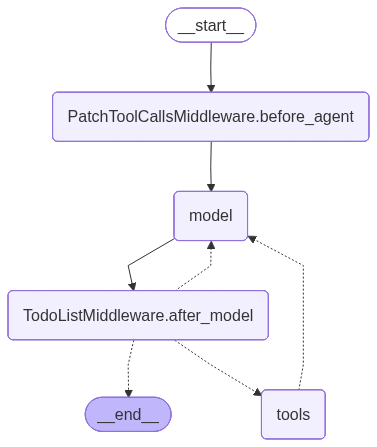

In [8]:
from datetime import datetime

research_subagent = {
    "name": "research-agent",
    "description": "Delegate commodities market research tasks. Give one commodity or theme at a time.",
    "system_prompt": f"""You are a commodities market research analyst. Today is {datetime.now().strftime('%Y-%m-%d')}.
Use tools to gather market intelligence — supply/demand drivers, price action, and macro catalysts.
Structure findings with clear headings and inline citations.
Limit to 3 search calls.""",
    "tools": [tavily_search],
}

agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="""You are a commodities trading desk coordinator.
Delegate market research to the research-agent using the task() tool.
NEVER search directly — always delegate.
Synthesize findings into a desk note for the traders.""",
    subagents=[research_subagent],
    checkpointer=MemorySaver(),
)
agent

In [9]:
config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Very lightly research the latest news moving the corn and soybean markets this week"}]
}, config=config)

print(result["messages"][-1].content[:1500])

This week in corn and soybean markets:

Corn:
- The upcoming USDA July WASDE report (due July 10) is awaited to update supply-demand estimates.
- U.S. old-crop corn ending stocks are expected lower, supported by strong exports.
- Weather recently moderated after heat stress, causing slight price softening.
- Weather remains a key yield uncertainty.

Soybeans:
- Soybean futures weakened due to dry weather and disappointing export sales.
- Old crop export sales are at a marketing year low; new crop sales also lag.
- Crop conditions are about 65% good-to-excellent.
- Weather impact on yields is in focus for July-August.

Other:
- Export demand is pivotal for both markets.
- No major new gov't policies or external shocks noted.
- Weather and USDA report updates dominate near-term market drivers.

Let me know if you want a deeper update or more details on any aspect.


## 1.4 Backends & Memory

By default, files live in ephemeral state (`StateBackend`). Use `CompositeBackend` to route paths — e.g. `/memories/` to persistent `StoreBackend` while everything else stays ephemeral.

`StoreBackend` is a database-backed store meant to persist memory across threads. Here we back it with a local SQLite file, but the LangGraph `Store` can be backed by the database of your choice (Postgres, etc.).


In [10]:
import sqlite3
from deepagents.backends import StateBackend, StoreBackend, CompositeBackend
from langgraph.store.sqlite import SqliteStore

MEMORY_DB = "deep_agents_memory.db"

def open_memory_store(path=MEMORY_DB):
    """Open (or create) a persistent SQLite-backed long-term memory store."""
    conn = sqlite3.connect(path, check_same_thread=False, isolation_level=None)
    store = SqliteStore(conn)
    store.setup()  # creates tables IF NOT EXISTS -> safe whether or not the DB exists
    return store

store = open_memory_store()

# Pass a CompositeBackend *instance* (not a factory)
backend = CompositeBackend(
    default=StateBackend(),                                  # ephemeral scratch space
    routes={
        "/memories/": StoreBackend(                          # persists across threads (SQLite on disk)
            store=store,
            namespace=lambda rt: ("memories", "shared"),
        ),
    },
)

agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt=(
        "You are a helpful assistant. Save important facts to /memories/ for future reference. "
        "ALWAYS check /memories files before answering any questions to ensure you don't miss relevant information."
    ),
    subagents=[research_subagent],
    backend=backend,
    store=store,
    checkpointer=MemorySaver(),
)

# Thread 1: agent saves a memory
config1 = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Remember that I trade the grains & oilseeds complex and my primary book is soybeans. Save this to /memories/preferences.md"}]
}, config=config1)
print("Thread 1:", result["messages"][-1].content)


Thread 1: I have saved your trading preference: You trade the grains & oilseeds complex, and your primary book is soybeans.


In [11]:
# Thread 2: different thread, but /memories/ persists via StoreBackend
config2 = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Which commodity complex do I trade, and what's my primary book? Check /memories/"}]
}, config=config2)
print("Thread 2:", result["messages"][-1].content)

Thread 2: You trade the grains & oilseeds commodity complex, and your primary book is soybeans.


## 1.5 Middleware: Pluggable Behavior

Middleware hooks into `wrap_model_call` (every LLM call) and `wrap_tool_call` (every tool call). This lets you inject rules, audit, or intercept without changing agent code.

<img src="../images/deepAgentMiddleware.png" style="width: auto; max-height: 380px; border-radius: 8px;">

### Built-in context management

Three strategies the deep-agent middleware uses to keep within the model's context window:

<img src="../images/Offloading Inputs LangChain.png" style="width: auto; max-height: 440px; border-radius: 8px;">

**Offload Large Inputs** — file write/edit tool calls leave the full content in conversation history. At ~85% context capacity, deep agents truncate older tool calls and replace them with a file-pointer reference.

<img src="../images/Offloading Results LangChain.png" style="width: auto; max-height: 440px; border-radius: 8px;">

**Offload Large Results** — tool results over ~20k tokens are written to the backend and swapped with a path + 10-line preview. The agent can re-read or grep the full content as needed.

<img src="../images/LangChain Summarization.png" style="width: auto; max-height: 440px; border-radius: 8px;">

**Conversation Summarization** — when there's nothing left to offload and context hits ~85% of `max_input_tokens`, history is summarized. Full messages move to `/conversation_history/`; a structured summary replaces them in working memory.


In [12]:
from langchain.agents.middleware import wrap_model_call, wrap_tool_call
from langchain_core.messages import SystemMessage

audit_log = []

@wrap_model_call
def compliance_rules(request, handler):
    """Inject trading-desk compliance rules into every LLM call."""
    rules = """## Trading Desk Compliance Rules
- Never include client account numbers, position sizes tied to a named counterparty, or credentials in responses
- Always cite sources when presenting market research and price levels
- Flag any request that could involve material non-public information (MNPI) or market manipulation
- Frame commentary as market color, not investment advice or a guaranteed outcome"""
    existing = request.system_message
    blocks = list(existing.content_blocks) if existing else []
    blocks.append({"type": "text", "text": f"\n\n{rules}"})
    return handler(request.override(system_message=SystemMessage(content_blocks=blocks)))

@wrap_tool_call
def audit_trail(request, handler):
    """Create an audit log entry for every tool call."""
    entry = {"tool": request.tool_call["name"], "timestamp": datetime.now().isoformat()}
    result = handler(request)
    entry["status"] = "success"
    audit_log.append(entry)
    return result

agent_with_middleware = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="You are a helpful commodities research assistant.",
    middleware=[compliance_rules, audit_trail],
    checkpointer=MemorySaver(),
)

config = {"configurable": {"thread_id": str(uuid7())}}
result = agent_with_middleware.invoke({
    "messages": [{"role": "user", "content": "What is the current outlook for wheat? Write a short summary to /summary.md"}]
}, config=config)

print(result["messages"][-1].content)
print(f"\n--- Audit Log ({len(audit_log)} entries) ---")
for entry in audit_log:
    print(f"  {entry['timestamp']}  {entry['tool']}  {entry['status']}")

The current outlook for wheat in 2026 is characterized by regional price variations with upward pressure in some markets due to tightening supply and strong export demand. U.S. wheat production is forecasted to decline significantly due to drought, leading to the smallest winter wheat harvest since 1965/66 and higher farm prices. Despite lower production in parts of the world, record global production and competition keep prices mixed globally. Geopolitical tensions and unpredictable weather events have contributed to market volatility and reduced yields. Overall, wheat prices are expected to show regional variability, driven by supply challenges, export demand, and geopolitical factors.

The summary has been saved to /summary.md.

--- Audit Log (3 entries) ---
  2026-07-09T15:41:08.251536  task  success
  2026-07-09T15:41:57.675811  write_file  success
  2026-07-09T15:42:03.852409  edit_file  success


## 1.6 HITL: Tool-Level Approval

Deep Agents supports `interrupt_on` — pause execution when specific tools are called. The human can approve, edit, or reject.

<img src="../images/deepAgentHITL.png" style="width: auto; max-height: 380px; border-radius: 8px;">


In [13]:
agent_with_hitl = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="You are a helpful commodities trading desk assistant.",
    checkpointer=MemorySaver(),
    interrupt_on={
        "write_file": True,
        "edit_file": True,
    },
)

config = {"configurable": {"thread_id": str(uuid7())}}
result = agent_with_hitl.invoke({
    "messages": [{"role": "user", "content": "Draft a trade idea note to /trade_idea.md: 'Long soybeans on tightening South American supply'"}]
}, config=config)

if result.get("__interrupt__"):
    interrupt_info = result["__interrupt__"][0].value
    for action in interrupt_info["action_requests"]:
        print(f"Paused — tool: {action['name']}, args: {action['args']}")
    print("\nWaiting for approval...")

Paused — tool: write_file, args: {'file_path': '/trade_idea.md', 'content': 'Trade Idea: Long Soybeans on Tightening South American Supply\n\nThesis:\nSouth American soybean supply is tightening due to various factors such as adverse weather conditions, logistical challenges, and increased domestic demand. This is expected to reduce export volumes from major producers like Brazil and Argentina in the near term.\n\nRationale:\n1. Weather disruptions in key growing regions are impacting crop yields.\n2. Rising internal consumption in South American countries is limiting export availability.\n3. Global demand for soybeans remains robust, supporting prices.\n4. The tightening supply backdrop suggests a bullish outlook on soybean prices.\n\nTrade Recommendation:\nEnter a long position in soybeans to capitalize on potential upside from supply constraints in South America, anticipating price appreciation as the market reflects reduced export availability.\n\nRisks:\n- Weather conditions could

In [14]:
# Approve and continue
if result.get("__interrupt__"):
    result = agent_with_hitl.invoke(
        Command(resume={"decisions": [{"type": "approve"}]}),
        config=config,
    )
    print("Approved!")
    print("Agent reply:", result["messages"][-1].content)
    print()
    print_files(result)


Approved!
Agent reply: Trade idea note has been drafted and saved to /trade_idea.md with the title "Long Soybeans on Tightening South American Supply."

VIRTUAL FILESYSTEM (in-memory, not on disk!)

  Path: '/trade_idea.md'
  --------------------------------------
  | Trade Idea: Long Soybeans on Tightening South American Supply
  | 
  | Thesis:
  | South American soybean supply is tightening due to various factors such as adverse weather conditions, logistical challenges, and increased domestic demand. This is expected to reduce export volumes from major producers like Brazil and Argentina in the near term.
  | 
  | Rationale:
  | 1. Weather disruptions in key growing regions are impacting crop yields.
  | 2. Rising internal consumption in South American countries is limiting export availability.
  | 3. Global demand for soybeans remains robust, supporting prices.
  | 4. The tightening supply backdrop suggests a bullish outlook on soybean prices.
  | 
  | Trade Recommendation:
  | Ent

## 1.7 AGENTS.md & Skills

`AGENTS.md` replaces hardcoded system prompts with an editable identity file. Skills are loaded on demand — the agent reads them only when the task matches.

In [15]:
from deepagents.backends.utils import create_file_data

agents_md = """# Commodities Desk Analyst

You are an expert commodities trading desk analyst covering the grains, oilseeds, and softs complexes.

## Workflow
1. Plan with write_todos
2. Delegate market research to research-agent via task()
3. Synthesize findings into a desk note
4. Save to /final_report.md

## Rules
- Delegate research, don't search directly
- Consolidate citations [1], [2], [3]
- Present market color, not investment advice
- Check /skills/ for output format instructions
"""

desk_note_skill = """---
name: desk-note
description: Write a morning desk note for traders. Use when asked for a desk note, market recap, or trade commentary.
---

# Desk Note Skill

- One-line bold headline with the key takeaway
- Sections: **Price Action**, **Supply/Demand Drivers**, **Catalysts to Watch**
- Bullet points, tight and scannable — traders skim this pre-open
- Close with a **Bias** line (constructive / neutral / bearish) and a one-line rationale
- Keep it under 250 words
"""

# The agent's identity lives in the /AGENTS.md file (seeded below) and is loaded
# via the `memory` parameter — no redundant `system_prompt` string.
agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    subagents=[research_subagent],
    memory=["/AGENTS.md"],
    skills=["/skills/"],
    checkpointer=MemorySaver(),
)

config = {"configurable": {"thread_id": uuid7()}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Research the soybean market briefly, then write a morning desk note about it."}],
    "files": {
        "/AGENTS.md": create_file_data(agents_md),
        "/skills/desk-note/SKILL.md": create_file_data(desk_note_skill),
    },
}, config=config)

print(result["messages"])

[HumanMessage(content='Research the soybean market briefly, then write a morning desk note about it.', additional_kwargs={}, response_metadata={}, id='4c49ba46-5317-4113-bed2-dffda9cf6573'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 6996, 'total_tokens': 7051, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c8455884c7', 'id': 'chatcmpl-DzprYNck1nSMuNvkqBNd7wfx3NCAu', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f489d-f726-7e82-b791-f8c242c796bc-0', tool_calls=[{'name': 'task', 'args': {'description': 'Conduct brief research on the current soybean market conditions, including production, demand, pric

## 1.8 The Complete Agent

All pieces together: tools, subagents, memory, middleware, HITL, AGENTS.md, and skills.

> `agents/research_agent.py` packages a minimal slice of this (no HITL, no FilesystemBackend) for Module 4's evals.


In [16]:
store = open_memory_store()  # same SQLite-backed long-term memory as section 1.4
audit_log = []  # reset

complete_backend = CompositeBackend(
    default=StateBackend(),
    routes={
        "/memories/": StoreBackend(
            store=store,
            namespace=lambda rt: ("memories", "shared"),
        ),
    },
)

complete_agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    subagents=[research_subagent],
    backend=complete_backend,
    store=store,
    middleware=[compliance_rules, audit_trail],
    checkpointer=MemorySaver(),
    interrupt_on={"write_file": True, "edit_file": True},
    memory=["/AGENTS.md"],
    skills=["/skills/"],
)

print("Complete agent created with:")
print("  - Custom tools (tavily_search)")
print("  - Subagents (research-agent)")
print("  - Memory (/memories/ -> StoreBackend on SQLite)")
print("  - Middleware (compliance rules + audit trail)")
print("  - HITL (interrupt on file writes)")
print("  - AGENTS.md + Skills")


Complete agent created with:
  - Custom tools (tavily_search)
  - Subagents (research-agent)
  - Memory (/memories/ -> StoreBackend on SQLite)
  - Middleware (compliance rules + audit trail)
  - HITL (interrupt on file writes)
  - AGENTS.md + Skills


In [17]:
# Drive the complete agent end-to-end.
# Exercises: subagent delegation, file writes (HITL-gated),
# /memories/ persistence, and middleware (audit + compliance).
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": str(uuid7())}}

# Seed AGENTS.md + the desk-note skill (same content as the 1.7 cell)
# so the agent has its identity and capabilities loaded.
seed_files = {
    "/AGENTS.md": create_file_data(agents_md),
    "/skills/desk-note/SKILL.md": create_file_data(desk_note_skill),
}

result = complete_agent.invoke({
    "messages": [HumanMessage(content=(
        "Research the current corn market briefly. "
        "Follow your AGENTS.md workflow: delegate research, write the desk note to /final_report.md, "
        "and save key takeaways to /memories/research_notes.md. "
        "Search at most once."
    ))],
    "files": seed_files,
}, config=config)

# The HITL middleware pauses on every write_file / edit_file. Approve them all.
while result.get("__interrupt__"):
    payload = result["__interrupt__"][0].value
    actions = payload.get("action_requests", [])
    for action in actions:
        print(f"  HITL pause -> approving {action['name']}: {action['args'].get('file_path','?')}")
    result = complete_agent.invoke(
        Command(resume={"decisions": [{"type": "approve"} for _ in actions]}),
        config=config,
    )

print("\nFinal reply:\n", result["messages"][-1].content[:600])
print()
# Show only files the agent wrote (skip the seed files we passed in).
seed_paths = set(seed_files.keys())
agent_files = {k: v for k, v in (result.get("files") or {}).items() if k not in seed_paths}
print_files({"files": agent_files}, header="FILES THE AGENT WROTE")

print(f"\nAudit log: {len(audit_log)} tool call(s) recorded by the audit middleware")
for entry in audit_log:
    print(f"  {entry['timestamp']}  {entry['tool']:20s} {entry['status']}")


  HITL pause -> approving write_file: /final_report.md
  HITL pause -> approving write_file: /memories/research_notes.md

Final reply:
 The current corn market is characterized by strong global demand versus supply deficits outside the U.S. and China, record-high U.S. ending stocks, and weather uncertainties due to heat stress and developing El Niño conditions. Corn futures softened from a February peak near $4.80 to around $4.12-$4.40 recently, reflecting abundant supplies but supported by strong export demand. Market sentiment is cautious to bearish near term, balancing abundant supply with yield and export demand risks. Key insights are saved to /memories/research_notes.md and a desk note summary to /final_report.md. Let me

FILES THE AGENT WROTE

  Path: '/final_report.md'
  --------------------------------------
  | Corn Market Desk Note – July 2026
  | 
  | 1. Supply-Demand Fundamentals:
  | - The global corn market in 2026 remains characterized by rising demand outpacing supply 

### Deep Agents Recap

| Feature | How | Built-in? |
|---------|-----|----------|
| **Harness** | `create_deep_agent()` | Filesystem, Planning, Summarization |
| **Custom tools** | `tools=[your_tool]` | Added to built-in tools |
| **Subagents** | `subagents=[{name, description, ...}]` | `task()` tool |
| **Memory** | `CompositeBackend` routing to `StoreBackend` | Path-based routing |
| **Middleware** | `middleware=[wrap_model_call, wrap_tool_call]` | Appended to built-in stack |
| **HITL** | `interrupt_on={"write_file": True}` | Configurable per tool |
| **AGENTS.md** | `memory=["/AGENTS.md"]` or `files={}` | Editable identity |
| **Skills** | `skills=["./skills/"]` or `files={}` | On-demand capabilities |